In [256]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cmocean 
import pandas as pd 
import astropy
from astropy import units as u
from astropy.coordinates import SkyCoord
import glob 
import os 
from mwprop.nemod import *
from mwprop.nemod.NE2025 import ne2025

import matplotlib.patheffects as pe

%matplotlib inline

plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

In [12]:
file = '/Users/user/Downloads/ATNF_catalogue.csv'
df = pd.read_csv(file, sep=';')
df = df.iloc[1:]
df = df.replace('*', np.nan)
df

,#,NAME,PSRJ,RAJ,DECJ,P0,P1,DM,RM,S400,DIST,VTRANS,Unnamed: 12
1,1.0,J0002+6216,J0002+6216,00:02:58.1,+62:16:09.4,0.115364,5.97e-15,218.60,NaN,NaN,6.357,1062.964,NaN
2,2.0,J0006+1834,J0006+1834,00:06:04.8,+18:34:59,0.693748,2.10e-15,11.40,-20.50,0.20,0.860,NaN,NaN
3,3.0,J0007+7303,J0007+7303,00:07:01.7,+73:03:07.4,0.315873,3.60e-13,NaN,NaN,NaN,1.400,NaN,NaN
4,4.0,J0011+08,J0011+08,00:11:34,+08:10,2.552870,NaN,24.90,-17.00,NaN,5.399,NaN,NaN
5,5.0,J0012+5431,J0012+5431,00:12:23.3,+54:31:40,3.025301,1.28e-16,131.30,NaN,NaN,5.427,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4347,4347.0,J2354-2250,J2354-2250,23:54:26,-22:51:53,0.557996,NaN,9.90,9.10,NaN,1.108,NaN,NaN
4348,4348.0,J2355+0051,J2355+0051,23:55:51.2,+00:51:09.5,0.003719,3.22e-21,11.15,-0.10,NaN,0.959,NaN,NaN
4349,4349.0,J2355+04,J2355+04,23:55:30,+04:43,0.958000,NaN,13.00,NaN,NaN,1.133,NaN,NaN
4350,4350.0,J2355+1523,J2355+1523,23:55:48.6,+15:23:19,1.094396,4.19e-16,26.00,NaN,NaN,3.444,NaN,NaN


[359]


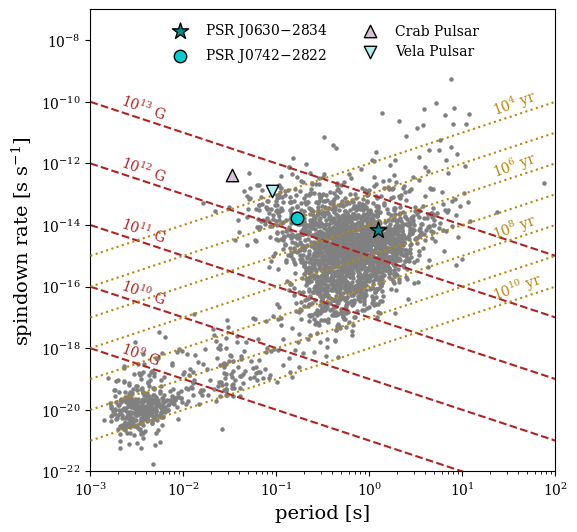

In [134]:
fig = plt.figure(figsize=(6,6))
xxx = df['P0'].values.astype('float')
yyy = df['P1'].values.astype('float')
plt.scatter(xxx, yyy, s=5, c='gray')
idx1 = np.where(df['PSRJ'].values=='J0630-2834')[0]
idx2 = np.where(df['PSRJ'].values=='J0742-2822')[0]
crab = 'J0534+2200'
vela = 'J0835-4510'
idxc = np.where(df['PSRJ'].values==crab)[0]
idxv = np.where(df['PSRJ'].values==vela)[0]
print(idx1)
plt.scatter(xxx[idx1], yyy[idx1], marker='*', s=150, ec='black', fc='darkcyan', label='PSR J0630$-$2834', zorder=4)
plt.scatter(xxx[idx2], yyy[idx2], marker='o', s=80, ec='black', fc='darkturquoise', label='PSR J0742$-$2822', zorder=4)
plt.scatter(xxx[idxc], yyy[idxc], marker='^', s=80, ec='black', fc='thistle', label='Crab Pulsar', zorder=4)
plt.scatter(xxx[idxv], yyy[idxv], marker='v', s=80, ec='black', fc='paleturquoise', label='Vela Pulsar', zorder=4)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('period [s]', size=14)
plt.ylabel('spindown rate [s s$^{-1}$]', size=14)

blinesb = [1e-18, 1e-16, 1e-14, 1e-12, 1e-10] # correct for P = 0.001 s
blinesl = ['10$^9$ G', '10$^{10}$ G', '10$^{11}$ G', '10$^{12}$ G', '10$^{13}$ G']

alinesb = [1e-18, 1e-17, 1e-16, 1e-15, 1e-14, 1e-13, 1e-12]
alinesl = ['10$^{10}$ yr', '10$^{9}$ yr', '10$^{8}$ yr', '10$^{7}$ yr', '10$^{6}$ yr', '10$^{5}$ yr', '10$^{4}$ yr']

for i, b in enumerate(blinesb):
    xl = np.logspace(-3, 2, 100)
    yl = 10**(-1*np.log10(xl)) * b*10**(-3)
    plt.plot(xl, yl, ls='--', c='firebrick', zorder=2)
    plt.text(2e-3, b*0.25, blinesl[i], color='firebrick', rotation=-20, zorder=4)

for i, a in enumerate(alinesb):
    xl = np.logspace(-3, 2, 100)
    yl = 10**(1*np.log10(xl)) * a
    plt.plot(xl, yl, ls=':', c='darkgoldenrod', zorder=3)
    if i%2 == 0:
        plt.text(2e1, a*35, alinesl[i], color='darkgoldenrod', rotation=20)

plt.xlim(1e-3, 1e2)
plt.ylim(1e-22, 1e-7)

plt.legend(ncol=2, loc='upper center', frameon=False)

plt.savefig('/Users/user/Downloads/HERA_pulsar_plots/Fig_PPdot_diagram.pdf', bbox_inches='tight')
plt.show()

In [123]:
ravec = df['RAJ'].values
decvec = df['DECJ'].values
print(ravec)
a_ravec = np.array([astropy.coordinates.Angle(ra + ' hours').radian for ra in ravec])
print(a_ravec)
a_decvec = np.array([astropy.coordinates.Angle(dec + ' degrees').radian for dec in decvec])

a_ravec_modified = []
for a in a_ravec:
    if a >= np.pi:
        new_a = a - 2*np.pi
    else:
        new_a = a
    a_ravec_modified.append(new_a)
a_ravec_modified = np.array(a_ravec_modified)

<ArrowStringArray>
['00:02:58.1', '00:06:04.8', '00:07:01.7',   '00:11:34', '00:12:23.3',
 '00:14:17.7', '00:21:51.4', '00:23:16.8', '00:23:50.3', '00:24:13.8',
 ...
   '23:50:42', '23:51:42.9',   '23:51:03',      '23:52', '23:54:04.7',
   '23:54:26', '23:55:51.2',   '23:55:30', '23:55:48.6', '23:55:49.8']
Length: 4351, dtype: str
[0.0129518  0.026529   0.03066689 ... 6.26355035 6.26490298 6.26499025]


In [ ]:
dvec = df['DIST'].values.astype('float')
svec = df['S400'].values.astype('float')
dmvec = df['DM'].values.astype('float')
rmvec = df['RM'].values.astype('float')

In [93]:
heralat = -1*(30+43/60+17/3600)

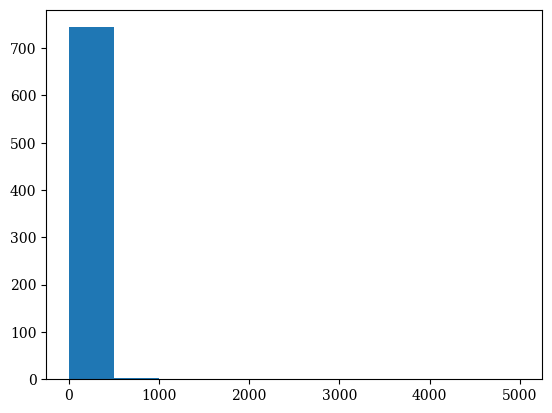

In [149]:
plt.hist(svec)
plt.show()

Crab brightness 550.0
Vela brightness 5000.0


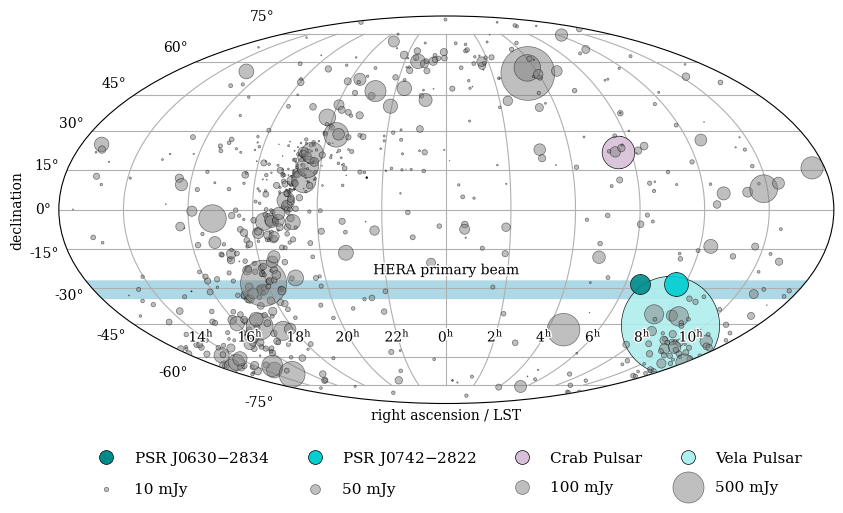

In [189]:
fig = plt.figure(figsize=(10,6))
ax = plt.axes(projection='mollweide')
ax.grid(True)
mask = np.ones_like(a_ravec_modified)
mask[idx1] = 0
mask[idx2] = 0
mask[idxc] = 0
mask[idxv] = 0
mask = mask.astype(bool)
s = ax.scatter(a_ravec_modified[mask], a_decvec[mask], s=svec[mask], lw=0.5, facecolors='gray', edgecolors='k', alpha=0.5, zorder=4)
print('Crab brightness', svec[idxc[0]])
print('Vela brightness', svec[idxv[0]])
s = ax.scatter(a_ravec_modified[idx1[0]], a_decvec[idx1[0]], s=1*svec[idx1[0]], lw=0.5, marker='o', facecolors='darkcyan', edgecolors='k', alpha=0.9, zorder=3)
s = ax.scatter(a_ravec_modified[idx2[0]], a_decvec[idx2[0]], s=1*svec[idx2[0]], lw=0.5, marker='o', facecolors='darkturquoise', edgecolors='k', alpha=0.9, zorder=3)
s = ax.scatter(a_ravec_modified[idxc[0]], a_decvec[idxc[0]], s=1*svec[idxc[0]], lw=0.5, marker='o', facecolors='thistle', edgecolors='k', alpha=0.9, zorder=2)
s = ax.scatter(a_ravec_modified[idxv[0]], a_decvec[idxv[0]], s=1*svec[idxv[0]], lw=0.5, marker='o', facecolors='paleturquoise', edgecolors='k', alpha=0.9, zorder=2)
plt.axhspan(heralat*np.pi/180-0.131/2, heralat*np.pi/180+0.131/2, color='lightblue', lw=0)
#plt.axhspan(heralat*np.pi/180+np.pi/2, np.pi/2, color='mistyrose', lw=0)
ax.text(0, -23*np.pi/180, 'HERA primary beam', ha='center', va='center', path_effects=[pe.withStroke(linewidth=2, foreground='white')], zorder=5)

#cax = ax.inset_axes([-120*np.pi/180, -50*np.pi/180, 240*np.pi/180, 7*np.pi/180], transform=ax.transData)
#fig.colorbar(s, cax=cax, orientation='horizontal', label='distance [kpc]')
ax.set_xlabel('right ascension / LST')
ax.set_ylabel('declination')
#help(ax.spines['geo'])
#print(ax.spines['geo'].get_position())
#ax.spines['geo'].set_position(('data', -35*np.pi/180))
#ax.tick_params(axis='x', which='major', pad=50)
ax.set_xticklabels([])
xticklabelvec = [r'14$^\mathrm{h}$', 
                    r'16$^\mathrm{h}$', 
                    r'18$^\mathrm{h}$',
                    r'20$^\mathrm{h}$', 
                    r'22$^\mathrm{h}$', 
                    r'0$^\mathrm{h}$',
                    r'2$^\mathrm{h}$',
                    r'4$^\mathrm{h}$',
                    r'6$^\mathrm{h}$',
                    r'8$^\mathrm{h}$', 
                    r'10$^\mathrm{h}$']
xtickvec = ax.get_xticks()
#print(xtickvec)
for i, x in enumerate(xticklabelvec):
    xpos = xtickvec[i]
    ax.text(xpos, -50*np.pi/180, x, ha='center', va='center',
            path_effects=[pe.withStroke(linewidth=2, foreground='white')], zorder=5)
    

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_elements = [Line2D([0], [0], markerfacecolor='darkcyan', markeredgecolor='k', marker='o', ms=10, mew=0.5, lw=0, label='PSR J0630$-$2834'),
                    Line2D([0], [0], markerfacecolor='gray', markeredgecolor='k', marker='o', ms=np.sqrt(10), lw=0, mew=0.5, alpha=0.5, label=r'10 mJy'),

                    Line2D([0], [0], markerfacecolor='darkturquoise', markeredgecolor='k', marker='o', ms=10, mew=0.5, lw=0, label='PSR J0742$-$2822'),
                    Line2D([0], [0], markerfacecolor='gray', markeredgecolor='k', marker='o', ms=np.sqrt(50), lw=0, mew=0.5, alpha=0.5, label=r'50 mJy'),

                    Line2D([0], [0], markerfacecolor='thistle', markeredgecolor='k', marker='o', ms=10, mew=0.5, lw=0, label='Crab Pulsar'),
                    Line2D([0], [0], markerfacecolor='gray', markeredgecolor='k', marker='o', ms=np.sqrt(100), lw=0, mew=0.5, alpha=0.5, label=r'100 mJy'),

                    Line2D([0], [0], markerfacecolor='paleturquoise', markeredgecolor='k', marker='o', ms=10, mew=0.5, lw=0, label='Vela Pulsar'),
                    Line2D([0], [0], markerfacecolor='gray', markeredgecolor='k', marker='o', ms=np.sqrt(500), lw=0, mew=0.5, alpha=0.5, label=r'500 mJy')]

plt.legend(handles=legend_elements, 
            loc='center', 
            bbox_to_anchor=[0.5, -0.18], 
            ncol=4, 
            labelspacing=1,
            framealpha=0.8,
            frameon=False,
            fontsize=11)

plt.savefig('/Users/user/Downloads/HERA_pulsar_plots/Fig_sky_distribution.pdf', bbox_inches='tight')
plt.show()

In [173]:
Dk,Dv,Du,Dd = ne2025(ldeg=45,bdeg=5,dmd=50,ndir=1,classic=False,dmd_only=False)
print(Dv['SBW'])

0.4162046442765872


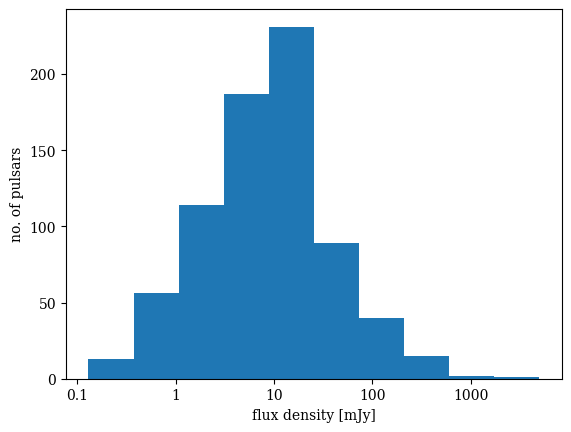

In [180]:
plt.hist(np.log10(svec[(~np.isnan(svec))&(svec>0)]))
plt.xlabel('flux density [mJy]')
plt.ylabel('no. of pulsars')
plt.xticks([-1, 0, 1, 2, 3])
plt.gca().set_xticklabels([0.1, 1, 10, 100, 1000])
plt.show()

In [193]:
sbw1GHz = []

for i in range(len(decvec)):
    if i%10 == 0:
        print(f'{i} of {len(decvec)}')
    ra = a_ravec[i]
    dec = a_decvec[i]
    dm = dmvec[i]
    # if svec[i] < 100:
    #     print('too dim; continuing ...')
    #     sbw1GHz.append(np.nan)
    #     continue
    if np.isnan(ra) or np.isnan(dec) or np.isnan(dm):
        print('nan position or DM; continuing ...')
        sbw1GHz.append(np.nan)
        continue

    c = SkyCoord(ra=ra*u.radian, dec=dec*u.radian, frame='icrs')
    g = c.galactic

    Dk,Dv,Du,Dd = ne2025(ldeg=g.l.deg,bdeg=g.b.deg,dmd=dm,ndir=1,classic=False,dmd_only=False)
    sbw = Dv['SBW'] # scintillation bandwidth in MHz, evaluated at 1 GHz
    sbw1GHz.append(sbw)

0 of 4351
nan position or DM; continuing ...
10 of 4351
20 of 4351
30 of 4351
40 of 4351
50 of 4351
60 of 4351
nan position or DM; continuing ...
70 of 4351
nan position or DM; continuing ...
80 of 4351
90 of 4351
100 of 4351
110 of 4351
nan position or DM; continuing ...
120 of 4351
130 of 4351
140 of 4351
150 of 4351
160 of 4351
170 of 4351
nan position or DM; continuing ...
180 of 4351
nan position or DM; continuing ...
190 of 4351
200 of 4351
nan position or DM; continuing ...
nan position or DM; continuing ...
210 of 4351
220 of 4351
230 of 4351
nan position or DM; continuing ...
240 of 4351
250 of 4351
260 of 4351
270 of 4351
nan position or DM; continuing ...
280 of 4351
290 of 4351
nan position or DM; continuing ...
300 of 4351
310 of 4351
nan position or DM; continuing ...
320 of 4351
330 of 4351
340 of 4351
nan position or DM; continuing ...
350 of 4351
360 of 4351
nan position or DM; continuing ...
nan position or DM; continuing ...
370 of 4351
380 of 4351
390 of 4351
400 of

In [194]:
np.savez('/Users/user/Downloads/sbw1GHz.npz', sbw=sbw1GHz)

In [198]:
sbw150 = np.array(sbw1GHz)*(150/1000)**(22/5)
print(sbw150[~np.isnan(sbw150)].min())

5.854723503111998e-14


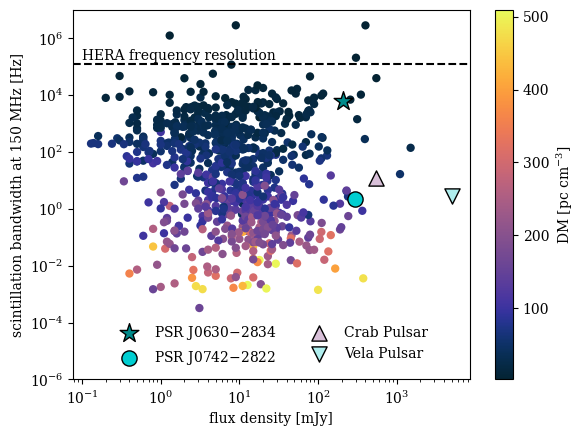

In [253]:
s = plt.scatter(svec[mask], sbw150[mask]*1e6, lw=0, c=dmvec[mask], cmap=cmocean.cm.thermal)
plt.scatter(svec[idx1], 1e6*sbw150[idx1], marker='*', s=200, ec='black', fc='darkcyan', label='PSR J0630$-$2834', zorder=4)
plt.scatter(svec[idx2], 1e6*sbw150[idx2], marker='o', s=120, ec='black', fc='darkturquoise', label='PSR J0742$-$2822', zorder=4)
plt.scatter(svec[idxc], 1e6*sbw150[idxc], marker='^', s=120, ec='black', fc='thistle', label='Crab Pulsar', zorder=4)
plt.scatter(svec[idxv], 1e6*sbw150[idxv], marker='v', s=120, ec='black', fc='paleturquoise', label='Vela Pulsar', zorder=4)
plt.text(0.1, 122e3*1.4, 'HERA frequency resolution')
plt.xscale('log')
plt.xlabel('flux density [mJy]')
plt.ylabel('scintillation bandwidth at 150 MHz [Hz]')
plt.yscale('log')
plt.axhline(122*1e3, c='k', ls='--')
plt.colorbar(s, label='DM [pc cm$^{-3}$]')
plt.ylim(1e-6, 1e7)
plt.legend(ncol=2, frameon=False, loc='lower center')
#plt.savefig('/Users/user/Downloads/HERA_pulsar_plots/Fig_scintillation_bandwidth_distribution.pdf', bbox_inches='tight')
plt.show()

In [249]:
print(np.min(sbw150[~np.isnan(sbw150)])*1e6)

5.8547235031119984e-08


Crab brightness 550.0
Vela brightness 5000.0
6057.521801357634


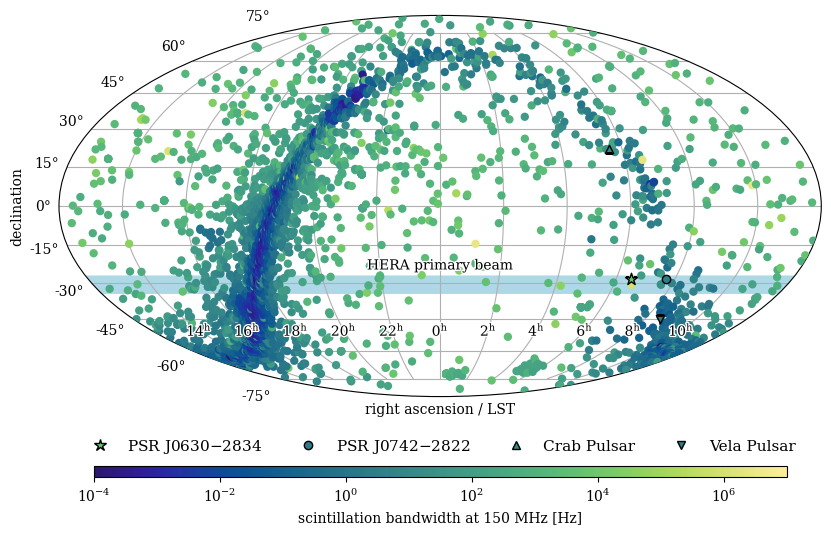

In [291]:
fig = plt.figure(figsize=(10,6))
ax = plt.axes(projection='mollweide')
ax.grid(True)
mask = np.ones_like(a_ravec_modified)
mask[idx1] = 0
mask[idx2] = 0
mask[idxc] = 0
mask[idxv] = 0
mask = mask.astype(bool)

cmap = cmocean.cm.haline
norm = mcolors.LogNorm(vmin=1e-4, vmax=1e7)

s0 = ax.scatter(a_ravec_modified[mask], a_decvec[mask], c=1e6*sbw150[mask], 
                vmin=1e-4, 
                vmax=1e7,
                cmap=cmap,
                lw=0, alpha=1, zorder=4, norm='log')
print('Crab brightness', svec[idxc[0]])
print('Vela brightness', svec[idxv[0]])
s = ax.scatter(a_ravec_modified[idx1[0]], a_decvec[idx1[0]], 
               color=cmap(norm(1e6*sbw150[idx1[0]])), 
            #    vmin=1e-4, 
            #     vmax=1e7,
                lw=1, marker='*', s=81, edgecolors='k', alpha=1, zorder=5)
print(1e6*sbw150[idx1[0]])
s = ax.scatter(a_ravec_modified[idx2[0]], a_decvec[idx2[0]], 
               color=cmap(norm(1e6*sbw150[idx2[0]])),
            #    vmin=np.min(sbw150[~np.isnan(sbw150)])*1e6, 
            #     vmax=np.max(sbw150[~np.isnan(sbw150)])*1e6,
                lw=1, marker='o', edgecolors='k', alpha=1, zorder=5)
s = ax.scatter(a_ravec_modified[idxc[0]], a_decvec[idxc[0]],
               color=cmap(norm(1e6*sbw150[idxc[0]])),
            #    vmin=np.min(sbw150[~np.isnan(sbw150)])*1e6, 
            #     vmax=np.max(sbw150[~np.isnan(sbw150)])*1e6,
                lw=1, marker='^', 
                edgecolors='k', 
                alpha=1, zorder=5)
s = ax.scatter(a_ravec_modified[idxv[0]], a_decvec[idxv[0]],
               color=cmap(norm(1e6*sbw150[idxv[0]])),
            #    vmin=np.min(sbw150[~np.isnan(sbw150)])*1e6, 
            #     vmax=np.max(sbw150[~np.isnan(sbw150)])*1e6,
                lw=1, marker='v', edgecolors='k', alpha=1, zorder=5)
plt.axhspan(heralat*np.pi/180-0.131/2, heralat*np.pi/180+0.131/2, color='lightblue', lw=0)
#plt.axhspan(heralat*np.pi/180+np.pi/2, np.pi/2, color='mistyrose', lw=0)
ax.text(0, -23*np.pi/180, 'HERA primary beam', ha='center', va='center', path_effects=[pe.withStroke(linewidth=2, foreground='white')], zorder=5)

#cax = ax.inset_axes([-120*np.pi/180, -50*np.pi/180, 240*np.pi/180, 7*np.pi/180], transform=ax.transData)
#fig.colorbar(s, cax=cax, orientation='horizontal', label='distance [kpc]')
ax.set_xlabel('right ascension / LST')
ax.set_ylabel('declination')
#help(ax.spines['geo'])
#print(ax.spines['geo'].get_position())
#ax.spines['geo'].set_position(('data', -35*np.pi/180))
#ax.tick_params(axis='x', which='major', pad=50)
ax.set_xticklabels([])
xticklabelvec = [r'14$^\mathrm{h}$', 
                    r'16$^\mathrm{h}$', 
                    r'18$^\mathrm{h}$',
                    r'20$^\mathrm{h}$', 
                    r'22$^\mathrm{h}$', 
                    r'0$^\mathrm{h}$',
                    r'2$^\mathrm{h}$',
                    r'4$^\mathrm{h}$',
                    r'6$^\mathrm{h}$',
                    r'8$^\mathrm{h}$', 
                    r'10$^\mathrm{h}$']
xtickvec = ax.get_xticks()
#print(xtickvec)
for i, x in enumerate(xticklabelvec):
    xpos = xtickvec[i]
    ax.text(xpos, -50*np.pi/180, x, ha='center', va='center',
            path_effects=[pe.withStroke(linewidth=2, foreground='white')], zorder=5)
    

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_elements = [Line2D([0], [0], markerfacecolor=cmap(norm(1e6*sbw150[idx1[0]])), markeredgecolor='k', marker='*', ms=9, mew=1, lw=0, label='PSR J0630$-$2834'),
                    #Line2D([0], [0], markerfacecolor='gray', markeredgecolor='k', marker='o', ms=np.sqrt(10), lw=0, mew=0.5, alpha=0.5, label=r'10 mJy'),

                    Line2D([0], [0], markerfacecolor=cmap(norm(1e6*sbw150[idx2[0]])), markeredgecolor='k', marker='o', ms=6, mew=1, lw=0, label='PSR J0742$-$2822'),
                    #Line2D([0], [0], markerfacecolor='gray', markeredgecolor='k', marker='o', ms=np.sqrt(50), lw=0, mew=0.5, alpha=0.5, label=r'50 mJy'),

                    Line2D([0], [0], markerfacecolor=cmap(norm(1e6*sbw150[idxc[0]])), markeredgecolor='k', marker='^', ms=6, mew=1, lw=0, label='Crab Pulsar'),
                    #Line2D([0], [0], markerfacecolor='gray', markeredgecolor='k', marker='o', ms=np.sqrt(100), lw=0, mew=0.5, alpha=0.5, label=r'100 mJy'),

                    Line2D([0], [0], markerfacecolor=cmap(norm(1e6*sbw150[idxv[0]])), markeredgecolor='k', marker='v', ms=6, mew=1, lw=0, label='Vela Pulsar'),
                    #Line2D([0], [0], markerfacecolor='gray', markeredgecolor='k', marker='o', ms=np.sqrt(500), lw=0, mew=0.5, alpha=0.5, label=r'500 mJy')
                    ]

plt.legend(handles=legend_elements, 
            loc='center', 
            bbox_to_anchor=[0.5, -0.13], 
            ncol=4, 
            labelspacing=1,
            framealpha=0.8,
            frameon=False,
            fontsize=11)

plt.colorbar(s0, orientation='horizontal', label='scintillation bandwidth at 150 MHz [Hz]',
             fraction=0.025,
             aspect=60
             )

plt.savefig('/Users/user/Downloads/HERA_pulsar_plots/Fig_sky_distribution_scintbw.pdf', bbox_inches='tight')
plt.show()

Crab brightness 550.0
Vela brightness 5000.0
6057.521801357634


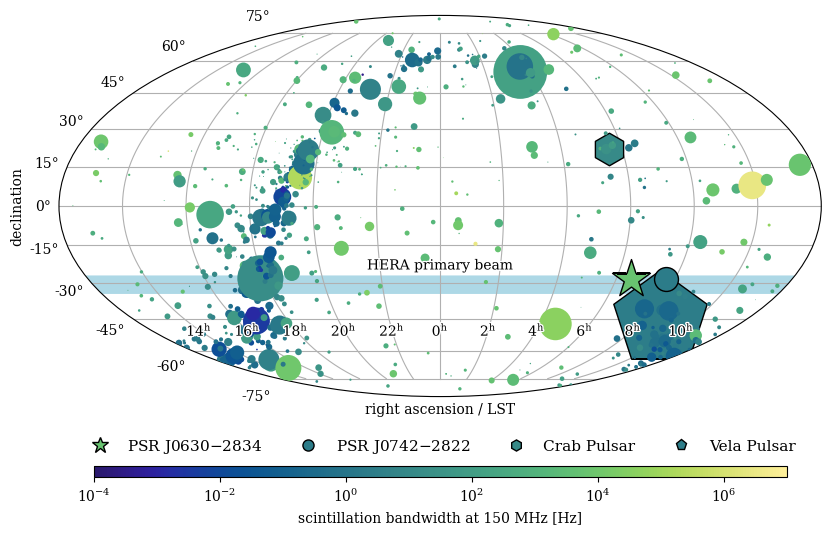

In [302]:
fig = plt.figure(figsize=(10,6))
ax = plt.axes(projection='mollweide')
ax.grid(True)
mask = np.ones_like(a_ravec_modified)
mask[idx1] = 0
mask[idx2] = 0
mask[idxc] = 0
mask[idxv] = 0
mask = mask.astype(bool)

cmap = cmocean.cm.haline
norm = mcolors.LogNorm(vmin=1e-4, vmax=1e7)

s0 = ax.scatter(a_ravec_modified[mask], a_decvec[mask], c=1e6*sbw150[mask], 
                s=svec[mask],
                vmin=1e-4, 
                vmax=1e7,
                cmap=cmap,
                lw=0, alpha=1, zorder=4, norm='log')
print('Crab brightness', svec[idxc[0]])
print('Vela brightness', svec[idxv[0]])
s = ax.scatter(a_ravec_modified[idx1[0]], a_decvec[idx1[0]], 
               color=cmap(norm(1e6*sbw150[idx1[0]])), 
               s=4*svec[idx1[0]],
            #    vmin=1e-4, 
            #     vmax=1e7,
                lw=1, marker='*', edgecolors='k', alpha=1, zorder=3)
print(1e6*sbw150[idx1[0]])
s = ax.scatter(a_ravec_modified[idx2[0]], a_decvec[idx2[0]], 
               color=cmap(norm(1e6*sbw150[idx2[0]])),
               s=1*svec[idx2[0]],
            #    vmin=np.min(sbw150[~np.isnan(sbw150)])*1e6, 
            #     vmax=np.max(sbw150[~np.isnan(sbw150)])*1e6,
                lw=1, marker='o', edgecolors='k', alpha=1, zorder=3)
s = ax.scatter(a_ravec_modified[idxc[0]], a_decvec[idxc[0]],
               color=cmap(norm(1e6*sbw150[idxc[0]])),
               s=1*svec[idxc[0]],
            #    vmin=np.min(sbw150[~np.isnan(sbw150)])*1e6, 
            #     vmax=np.max(sbw150[~np.isnan(sbw150)])*1e6,
                lw=1, marker='h', 
                edgecolors='k', 
                alpha=1, zorder=3)
s = ax.scatter(a_ravec_modified[idxv[0]], a_decvec[idxv[0]],
               color=cmap(norm(1e6*sbw150[idxv[0]])),
               s=1*svec[idxv[0]],
            #    vmin=np.min(sbw150[~np.isnan(sbw150)])*1e6, 
            #     vmax=np.max(sbw150[~np.isnan(sbw150)])*1e6,
                lw=1, marker='p', edgecolors='k', alpha=1, zorder=2)
plt.axhspan(heralat*np.pi/180-0.131/2, heralat*np.pi/180+0.131/2, color='lightblue', lw=0)
#plt.axhspan(heralat*np.pi/180+np.pi/2, np.pi/2, color='mistyrose', lw=0)
ax.text(0, -23*np.pi/180, 'HERA primary beam', ha='center', va='center', path_effects=[pe.withStroke(linewidth=2, foreground='white')], zorder=5)

#cax = ax.inset_axes([-120*np.pi/180, -50*np.pi/180, 240*np.pi/180, 7*np.pi/180], transform=ax.transData)
#fig.colorbar(s, cax=cax, orientation='horizontal', label='distance [kpc]')
ax.set_xlabel('right ascension / LST')
ax.set_ylabel('declination')
#help(ax.spines['geo'])
#print(ax.spines['geo'].get_position())
#ax.spines['geo'].set_position(('data', -35*np.pi/180))
#ax.tick_params(axis='x', which='major', pad=50)
ax.set_xticklabels([])
xticklabelvec = [r'14$^\mathrm{h}$', 
                    r'16$^\mathrm{h}$', 
                    r'18$^\mathrm{h}$',
                    r'20$^\mathrm{h}$', 
                    r'22$^\mathrm{h}$', 
                    r'0$^\mathrm{h}$',
                    r'2$^\mathrm{h}$',
                    r'4$^\mathrm{h}$',
                    r'6$^\mathrm{h}$',
                    r'8$^\mathrm{h}$', 
                    r'10$^\mathrm{h}$']
xtickvec = ax.get_xticks()
#print(xtickvec)
for i, x in enumerate(xticklabelvec):
    xpos = xtickvec[i]
    ax.text(xpos, -50*np.pi/180, x, ha='center', va='center',
            path_effects=[pe.withStroke(linewidth=2, foreground='white')], zorder=5)
    

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_elements = [Line2D([0], [0], markerfacecolor=cmap(norm(1e6*sbw150[idx1[0]])), markeredgecolor='k', marker='*', ms=12, mew=1, lw=0, label='PSR J0630$-$2834'),
                    #Line2D([0], [0], markerfacecolor='gray', markeredgecolor='k', marker='o', ms=np.sqrt(10), lw=0, mew=0.5, alpha=0.5, label=r'10 mJy'),

                    Line2D([0], [0], markerfacecolor=cmap(norm(1e6*sbw150[idx2[0]])), markeredgecolor='k', marker='o', ms=8, mew=1, lw=0, label='PSR J0742$-$2822'),
                    #Line2D([0], [0], markerfacecolor='gray', markeredgecolor='k', marker='o', ms=np.sqrt(50), lw=0, mew=0.5, alpha=0.5, label=r'50 mJy'),

                    Line2D([0], [0], markerfacecolor=cmap(norm(1e6*sbw150[idxc[0]])), markeredgecolor='k', marker='h', ms=8, mew=1, lw=0, label='Crab Pulsar'),
                    #Line2D([0], [0], markerfacecolor='gray', markeredgecolor='k', marker='o', ms=np.sqrt(100), lw=0, mew=0.5, alpha=0.5, label=r'100 mJy'),

                    Line2D([0], [0], markerfacecolor=cmap(norm(1e6*sbw150[idxv[0]])), markeredgecolor='k', marker='p', ms=8, mew=1, lw=0, label='Vela Pulsar'),
                    #Line2D([0], [0], markerfacecolor='gray', markeredgecolor='k', marker='o', ms=np.sqrt(500), lw=0, mew=0.5, alpha=0.5, label=r'500 mJy')
                    ]

plt.legend(handles=legend_elements, 
            loc='center', 
            bbox_to_anchor=[0.5, -0.13], 
            ncol=4, 
            labelspacing=1,
            framealpha=0.8,
            frameon=False,
            fontsize=11)

plt.colorbar(s0, orientation='horizontal', label='scintillation bandwidth at 150 MHz [Hz]',
             fraction=0.025,
             aspect=60
             )

plt.savefig('/Users/user/Downloads/HERA_pulsar_plots/Fig_sky_distribution_scintbw_brightness.pdf', bbox_inches='tight')
plt.show()

In [319]:
print(len(svec[np.isnan(svec)]))
print(len(svec))

3602
4351


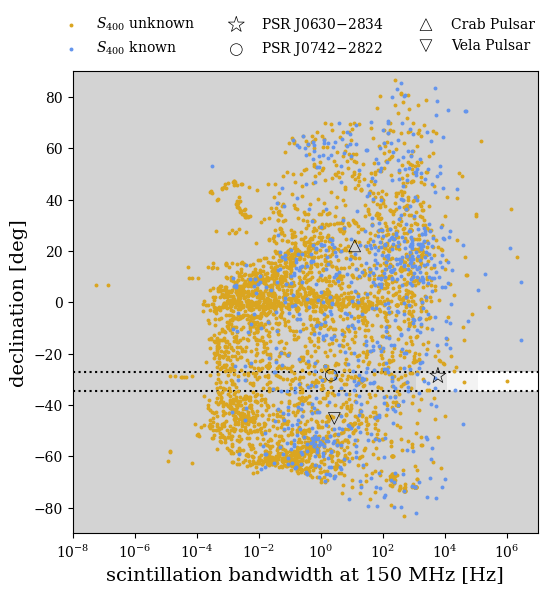

In [375]:
fig = plt.figure(figsize=(6,6))
plt.scatter(1e6*sbw150[np.isnan(svec)], a_decvec[np.isnan(svec)]*180/np.pi, lw=0, s=8, color='goldenrod', zorder=2, label='$S_{400}$ unknown')
plt.scatter(1e6*sbw150[mask][~np.isnan(svec[mask])], a_decvec[mask][~np.isnan(svec[mask])]*180/np.pi, lw=0, s=8, color='cornflowerblue', zorder=2, label='$S_{400}$ known')
plt.scatter(1e6*sbw150[idx1[0]], a_decvec[idx1[0]]*180/np.pi, lw=0.5, s=36*4, marker='*', color='none', ec='k', zorder=3, label='PSR J0630$-$2834')
plt.scatter(1e6*sbw150[idx2[0]], a_decvec[idx2[0]]*180/np.pi, lw=0.5, s=36*2, marker='o', color='none', ec='k', zorder=3, label='PSR J0742$-$2822')
plt.scatter(1e6*sbw150[idxc[0]], a_decvec[idxc[0]]*180/np.pi, lw=0.5, s=36*2, marker='^', color='none', ec='k', zorder=3, label='Crab Pulsar')
plt.scatter(1e6*sbw150[idxv[0]], a_decvec[idxv[0]]*180/np.pi, lw=0.5, s=36*2, marker='v', color='none', ec='k', zorder=3, label='Vela Pulsar')
plt.xscale('log')
plt.xlabel('scintillation bandwidth at 150 MHz [Hz]', size=14)
plt.ylabel('declination [deg]', size=14)
plt.axhspan(heralat+0.131*180/np.pi/2, 90, color='lightgray', lw=0, alpha=1, zorder=0)
plt.axhspan(-90, heralat-0.131*180/np.pi/2, color='lightgray', lw=0, alpha=1, zorder=0)
plt.axvspan(1e-8, 122e1, color='lightgray', lw=0, alpha=1, zorder=0)
plt.axvspan(1e-8, 122e2, color='lightgray', lw=0, alpha=0.5, zorder=0)
plt.axvspan(1e-8, 122e3, color='lightgray', lw=0, alpha=0.25, zorder=0)
plt.axhline(heralat-0.131*180/np.pi/2, color='k', ls=':', zorder=0)
plt.axhline(heralat+0.131*180/np.pi/2, color='k', ls=':', zorder=0)
plt.ylim(-90,90)
plt.xlim(1e-8, 1e7)
plt.legend(frameon=False, ncol=3, loc='center', 
            bbox_to_anchor=[0.48, 1.075])
plt.savefig('/Users/user/Downloads/HERA_pulsar_plots/Fig_latitude_scintbw_check.pdf', bbox_inches='tight')
plt.show()

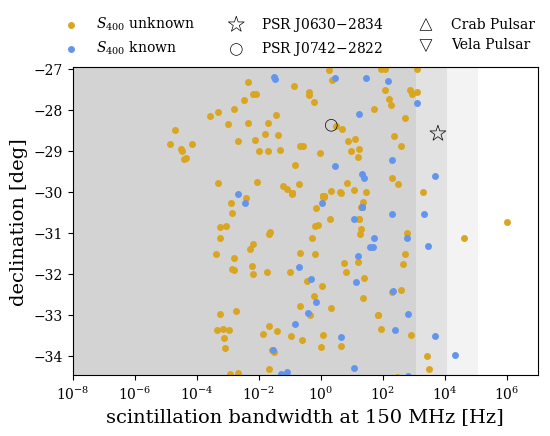

In [ ]:
fig = plt.figure(figsize=(6,4))
plt.scatter(1e6*sbw150[np.isnan(svec)], a_decvec[np.isnan(svec)]*180/np.pi, lw=0, s=25,
            color='goldenrod', zorder=2, label='$S_{400}$ unknown')
plt.scatter(1e6*sbw150[mask][~np.isnan(svec[mask])], a_decvec[mask][~np.isnan(svec[mask])]*180/np.pi, lw=0, 
            s=25, 
            color='cornflowerblue', zorder=2, label='$S_{400}$ known')

plt.scatter(1e6*sbw150[idx1[0]], a_decvec[idx1[0]]*180/np.pi, lw=0.5, s=36*4, marker='*', color='none', ec='k', zorder=3, label='PSR J0630$-$2834')
plt.scatter(1e6*sbw150[idx2[0]], a_decvec[idx2[0]]*180/np.pi, lw=0.5, s=36*2, marker='o', color='none', ec='k', zorder=3, label='PSR J0742$-$2822')
plt.scatter(1e6*sbw150[idxc[0]], a_decvec[idxc[0]]*180/np.pi, lw=0.5, s=36*2, marker='^', color='none', ec='k', zorder=3, label='Crab Pulsar')
plt.scatter(1e6*sbw150[idxv[0]], a_decvec[idxv[0]]*180/np.pi, lw=0.5, s=36*2, marker='v', color='none', ec='k', zorder=3, label='Vela Pulsar')
plt.xscale('log')
plt.xlabel('scintillation bandwidth at 150 MHz [Hz]', size=14)
plt.ylabel('declination [deg]', size=14)
plt.axhspan(heralat+0.131*180/np.pi/2, 90, color='lightgray', lw=0, alpha=1, zorder=0)
plt.axhspan(-90, heralat-0.131*180/np.pi/2, color='lightgray', lw=0, alpha=1, zorder=0)
plt.axvspan(1e-8, 122e1, color='lightgray', lw=0, alpha=1, zorder=0)
plt.axvspan(1e-8, 122e2, color='lightgray', lw=0, alpha=0.5, zorder=0)
plt.axvspan(1e-8, 122e3, color='lightgray', lw=0, alpha=0.25, zorder=0)
#plt.axhline(heralat-0.131*180/np.pi/2, color='k', ls=':', zorder=0)
#plt.axhline(heralat+0.131*180/np.pi/2, color='k', ls=':', zorder=0)
plt.ylim(heralat-0.131*180/np.pi/2,heralat+0.131*180/np.pi/2)
plt.xlim(1e-8, 1e7)
plt.legend(frameon=False, ncol=3, loc='center', 
            bbox_to_anchor=[0.48, 1.1])
plt.savefig('/Users/user/Downloads/HERA_pulsar_plots/Fig_latitude_scintbw_check_zoomin.pdf', bbox_inches='tight')
plt.show()

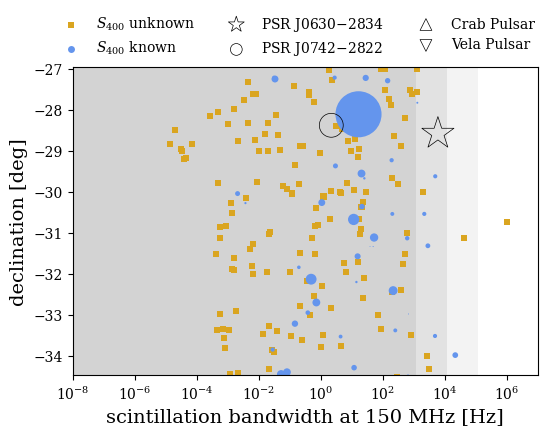

In [385]:
fig = plt.figure(figsize=(6,4))
plt.scatter(1e6*sbw150[np.isnan(svec)], a_decvec[np.isnan(svec)]*180/np.pi, lw=0, s=25, marker='s',
            color='goldenrod', zorder=2, label='$S_{400}$ unknown')
plt.scatter(1e6*sbw150[mask][~np.isnan(svec[mask])], a_decvec[mask][~np.isnan(svec[mask])]*180/np.pi, lw=0, 
            s=svec[mask][~np.isnan(svec[mask])], 
            color='cornflowerblue', zorder=2)

# for label only
plt.scatter(1e10, 0, lw=0, 
            s=25, 
            color='cornflowerblue', zorder=2, label='$S_{400}$ known')
plt.scatter(1e10, 0, lw=0.5, s=36*4, marker='*', color='none', ec='k', zorder=3, label='PSR J0630$-$2834')
plt.scatter(1e10, 0, lw=0.5, s=36*2, marker='o', color='none', ec='k', zorder=3, label='PSR J0742$-$2822')
plt.scatter(1e10, 0, lw=0.5, s=36*2, marker='^', color='none', ec='k', zorder=3, label='Crab Pulsar')
plt.scatter(1e10, 0, lw=0.5, s=36*2, marker='v', color='none', ec='k', zorder=3, label='Vela Pulsar')

plt.scatter(1e6*sbw150[idx1[0]], a_decvec[idx1[0]]*180/np.pi, lw=0.5, s=2*svec[idx2[0]], marker='*', color='none', ec='k', zorder=3)
plt.scatter(1e6*sbw150[idx2[0]], a_decvec[idx2[0]]*180/np.pi, lw=0.5, s=svec[idx2[0]], marker='o', color='none', ec='k', zorder=3)
plt.scatter(1e6*sbw150[idxc[0]], a_decvec[idxc[0]]*180/np.pi, lw=0.5, s=svec[idx2[0]], marker='^', color='none', ec='k', zorder=3)
plt.scatter(1e6*sbw150[idxv[0]], a_decvec[idxv[0]]*180/np.pi, lw=0.5, s=svec[idx2[0]], marker='v', color='none', ec='k', zorder=3)
plt.xscale('log')
plt.xlabel('scintillation bandwidth at 150 MHz [Hz]', size=14)
plt.ylabel('declination [deg]', size=14)
plt.axhspan(heralat+0.131*180/np.pi/2, 90, color='lightgray', lw=0, alpha=1, zorder=0)
plt.axhspan(-90, heralat-0.131*180/np.pi/2, color='lightgray', lw=0, alpha=1, zorder=0)
plt.axvspan(1e-8, 122e1, color='lightgray', lw=0, alpha=1, zorder=0)
plt.axvspan(1e-8, 122e2, color='lightgray', lw=0, alpha=0.5, zorder=0)
plt.axvspan(1e-8, 122e3, color='lightgray', lw=0, alpha=0.25, zorder=0)
#plt.axhline(heralat-0.131*180/np.pi/2, color='k', ls=':', zorder=0)
#plt.axhline(heralat+0.131*180/np.pi/2, color='k', ls=':', zorder=0)
plt.ylim(heralat-0.131*180/np.pi/2,heralat+0.131*180/np.pi/2)
plt.xlim(1e-8, 1e7)
plt.legend(frameon=False, ncol=3, loc='center', 
            bbox_to_anchor=[0.48, 1.1])
plt.savefig('/Users/user/Downloads/HERA_pulsar_plots/Fig_latitude_scintbw_check_zoomin_brightness.pdf', bbox_inches='tight')
plt.show()

In [403]:
icheck = np.where(
    (a_decvec > heralat*np.pi/180-0.131/2) &
    (a_decvec < heralat*np.pi/180+0.131/2) &  
    (sbw150*1e6 > 1) &  
    ((np.isnan(svec)) | (svec > 100))
)
dfc = df.iloc[icheck]
sbwc = sbw150[icheck]
for i in range(len(dfc)):
    psr = dfc['PSRJ'].values[i]
    lst = dfc['RAJ'].values[i]
    dec = dfc['DECJ'].values[i]
    s400 = dfc['S400'].values[i]
    dist = dfc['DIST'].values[i]
    dm = dfc['DM'].values[i]
    sbw = sbwc[i]
    print(f'PSR {psr.ljust(12)} | LST {lst.ljust(12)} | decl. {dec.ljust(12)} | BWscint @ 150 MHz: {(str(round(sbw*1e6))+' Hz').ljust(10)} | DM: {dm} pc/cc | dist: {dist} kpc | S @ 400 MHz: {s400} mJy')

PSR J0343-3000   | LST 03:43:27.9   | decl. -30:00:27.5  | BWscint @ 150 MHz: 2065 Hz    | DM: 20.26 pc/cc | dist: 1.594 kpc | S @ 400 MHz: nan mJy
PSR J0410-31     | LST 04:10:39     | decl. -31:07:29    | BWscint @ 150 MHz: 41107 Hz   | DM: 9.20 pc/cc | dist: 0.415 kpc | S @ 400 MHz: nan mJy
PSR J0452-3418   | LST 04:52:00.7   | decl. -34:18:42    | BWscint @ 150 MHz: 3097 Hz    | DM: 19.78 pc/cc | dist: 1.342 kpc | S @ 400 MHz: nan mJy
PSR J0557-2948   | LST 05:57:32.9   | decl. -29:48:16.8  | BWscint @ 150 MHz: 317 Hz     | DM: 49.03 pc/cc | dist: 4.268 kpc | S @ 400 MHz: nan mJy
PSR J0614-3329   | LST 06:14:10.3   | decl. -33:29:54.1  | BWscint @ 150 MHz: 797 Hz     | DM: 37.05 pc/cc | dist: 0.667 kpc | S @ 400 MHz: nan mJy
PSR J0630-2834   | LST 06:30:49.4   | decl. -28:34:42.7  | BWscint @ 150 MHz: 6058 Hz    | DM: 34.42 pc/cc | dist: 0.320 kpc | S @ 400 MHz: 206.00 mJy
PSR J0636-3044   | LST 06:36:34.3   | decl. -30:44:01.1  | BWscint @ 150 MHz: 1009418 Hz | DM: 15.46 pc/cc | d

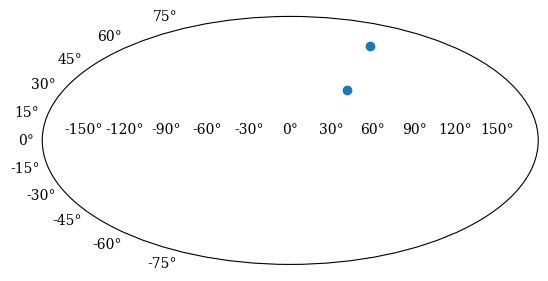

In [405]:
plt.subplot(projection='mollweide')
xxx = [np.pi/4, np.pi/2]
yyy = [np.pi/6, np.pi/3]
plt.scatter(xxx, yyy)
plt.show()

1.3617210531012303e-07
2853290.5881758817


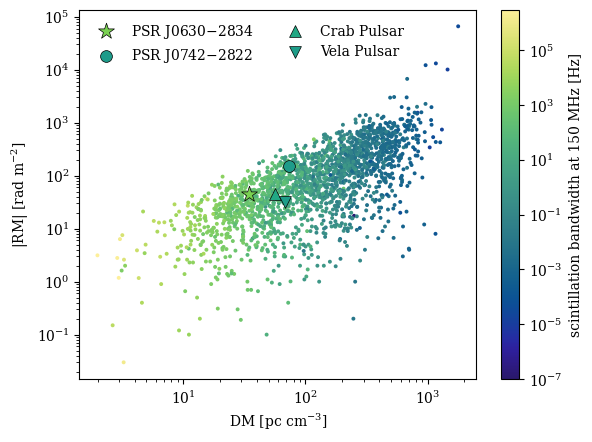

In [ ]:
cmap = cmocean.cm.haline
print(np.min(sbw150[~np.isnan(sbw150)&~np.isnan(rmvec)&~np.isnan(dmvec)]*1e6))
print(np.max(sbw150[~np.isnan(sbw150)&~np.isnan(rmvec)&~np.isnan(dmvec)]*1e6))
s=plt.scatter(dmvec, np.abs(rmvec), alpha=1, s=8, c=sbw150*1e6, cmap=cmap, norm='log', 
              vmin=1e-7, vmax=3e6, 
              lw=0)
plt.scatter(dmvec[idx1[0]], np.abs(rmvec)[idx1[0]], lw=0.5, s=36*4, marker='*', 
            c=1e6*sbw150[idx1[0]], norm='log', vmin=1e-7, vmax=3e6, ec='k', zorder=3, label='PSR J0630$-$2834')
plt.scatter(dmvec[idx2[0]], np.abs(rmvec)[idx2[0]], lw=0.5, s=36*2, marker='o', 
            c=1e6*sbw150[idx2[0]], norm='log', vmin=1e-7, vmax=3e6, ec='k', zorder=3, label='PSR J0742$-$2822')
plt.scatter(dmvec[idxc[0]], np.abs(rmvec)[idxc[0]], lw=0.5, s=36*2, marker='^', 
            c=1e6*sbw150[idxc[0]], norm='log', vmin=1e-7, vmax=3e6, ec='k', zorder=3, label='Crab Pulsar')
plt.scatter(dmvec[idxv[0]], np.abs(rmvec)[idxv[0]], lw=0.5, s=36*2, marker='v', 
            c=1e6*sbw150[idxv[0]], norm='log', vmin=1e-7, vmax=3e6, ec='k', zorder=3, label='Vela Pulsar')
plt.xlabel('DM [pc cm$^{-3}$]')
plt.ylabel('|RM| [rad m$^{-2}$]')
plt.xscale('log')
plt.yscale('log')
plt.colorbar(s, label='scintillation bandwidth at 150 MHz [Hz]')
plt.legend(ncol=2, frameon=False)
plt.show()

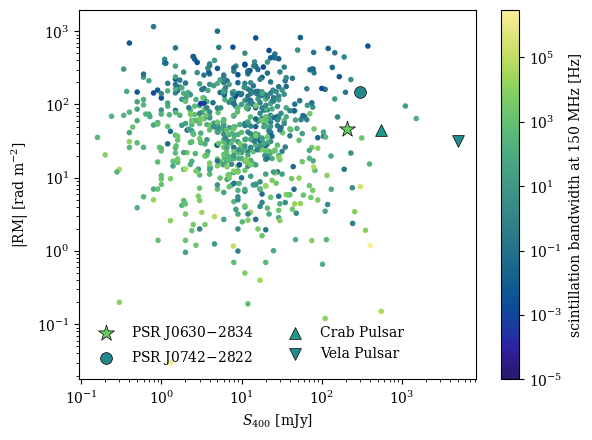

In [452]:
cmap = cmocean.cm.haline
s=plt.scatter(svec[mask], np.abs(rmvec[mask]), alpha=1, s=16, c=sbw150[mask]*1e6, cmap=cmap, norm='log', 
              vmin=1e-5, vmax=3e6, 
              lw=0)
plt.scatter(svec[idx1[0]], np.abs(rmvec)[idx1[0]], lw=0.5, s=36*4, marker='*', 
            c=1e6*sbw150[idx1[0]], norm='log', vmin=1e-5, vmax=3e6, ec='k', zorder=3, label='PSR J0630$-$2834')
plt.scatter(svec[idx2[0]], np.abs(rmvec)[idx2[0]], lw=0.5, s=36*2, marker='o', 
            c=1e6*sbw150[idx2[0]], norm='log', vmin=1e-5, vmax=3e6, ec='k', zorder=3, label='PSR J0742$-$2822')
plt.scatter(svec[idxc[0]], np.abs(rmvec)[idxc[0]], lw=0.5, s=36*2, marker='^', 
            c=1e6*sbw150[idxc[0]], norm='log', vmin=1e-5, vmax=3e6, ec='k', zorder=3, label='Crab Pulsar')
plt.scatter(svec[idxv[0]], np.abs(rmvec)[idxv[0]], lw=0.5, s=36*2, marker='v', 
            c=1e6*sbw150[idxv[0]], norm='log', vmin=1e-5, vmax=3e6, ec='k', zorder=3, label='Vela Pulsar')
plt.xlabel('$S_{400}$ [mJy]')
plt.ylabel('|RM| [rad m$^{-2}$]')
plt.xscale('log')
plt.yscale('log')
plt.colorbar(s, label='scintillation bandwidth at 150 MHz [Hz]')
plt.legend(ncol=2, frameon=False)
plt.savefig('/Users/user/Downloads/HERA_pulsar_plots/Fig_RM_brightness.pdf', bbox_inches='tight')
plt.show()

Crab brightness 550.0
Vela brightness 5000.0
J0630-2834 RM 45.78
6057.521801357634


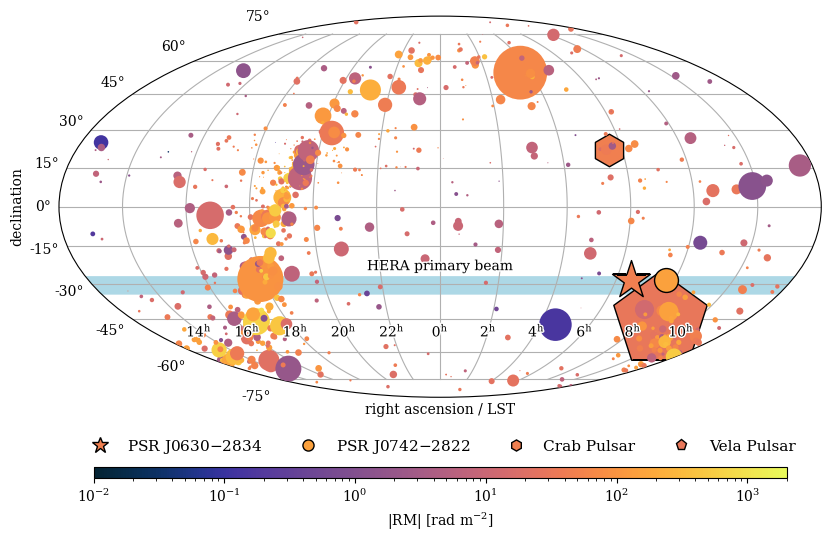

In [453]:
fig = plt.figure(figsize=(10,6))
ax = plt.axes(projection='mollweide')
ax.grid(True)
mask = np.ones_like(a_ravec_modified)
mask[idx1] = 0
mask[idx2] = 0
mask[idxc] = 0
mask[idxv] = 0
mask = mask.astype(bool)
armvec = np.abs(rmvec)

cmap = cmocean.cm.thermal
norm = mcolors.LogNorm(vmin=1e-2, vmax=2e3)

s0 = ax.scatter(a_ravec_modified[mask], a_decvec[mask], c=armvec[mask], 
                s=svec[mask],
                vmin=1e-2, 
                vmax=2e3,
                cmap=cmap,
                lw=0, alpha=1, zorder=4, norm='log')
print('Crab brightness', svec[idxc[0]])
print('Vela brightness', svec[idxv[0]])
s = ax.scatter(a_ravec_modified[idx1[0]], a_decvec[idx1[0]], 
               color=cmap(norm(armvec[idx1[0]])), 
               s=4*svec[idx1[0]],
            #    vmin=1e-4, 
            #     vmax=1e7,
                lw=1, marker='*', edgecolors='k', alpha=1, zorder=3)
print('J0630-2834 RM', armvec[idx1[0]])
print(1e6*sbw150[idx1[0]])
s = ax.scatter(a_ravec_modified[idx2[0]], a_decvec[idx2[0]], 
               color=cmap(norm(armvec[idx2[0]])),
               s=1*svec[idx2[0]],
            #    vmin=np.min(sbw150[~np.isnan(sbw150)])*1e6, 
            #     vmax=np.max(sbw150[~np.isnan(sbw150)])*1e6,
                lw=1, marker='o', edgecolors='k', alpha=1, zorder=3)
s = ax.scatter(a_ravec_modified[idxc[0]], a_decvec[idxc[0]],
               color=cmap(norm(armvec[idxc[0]])),
               s=1*svec[idxc[0]],
            #    vmin=np.min(sbw150[~np.isnan(sbw150)])*1e6, 
            #     vmax=np.max(sbw150[~np.isnan(sbw150)])*1e6,
                lw=1, marker='h', 
                edgecolors='k', 
                alpha=1, zorder=3)
s = ax.scatter(a_ravec_modified[idxv[0]], a_decvec[idxv[0]],
               color=cmap(norm(armvec[idxv[0]])),
               s=1*svec[idxv[0]],
            #    vmin=np.min(sbw150[~np.isnan(sbw150)])*1e6, 
            #     vmax=np.max(sbw150[~np.isnan(sbw150)])*1e6,
                lw=1, marker='p', edgecolors='k', alpha=1, zorder=2)
plt.axhspan(heralat*np.pi/180-0.131/2, heralat*np.pi/180+0.131/2, color='lightblue', lw=0)
#plt.axhspan(heralat*np.pi/180+np.pi/2, np.pi/2, color='mistyrose', lw=0)
ax.text(0, -23*np.pi/180, 'HERA primary beam', ha='center', va='center', path_effects=[pe.withStroke(linewidth=2, foreground='white')], zorder=5)

#cax = ax.inset_axes([-120*np.pi/180, -50*np.pi/180, 240*np.pi/180, 7*np.pi/180], transform=ax.transData)
#fig.colorbar(s, cax=cax, orientation='horizontal', label='distance [kpc]')
ax.set_xlabel('right ascension / LST')
ax.set_ylabel('declination')
#help(ax.spines['geo'])
#print(ax.spines['geo'].get_position())
#ax.spines['geo'].set_position(('data', -35*np.pi/180))
#ax.tick_params(axis='x', which='major', pad=50)
ax.set_xticklabels([])
xticklabelvec = [r'14$^\mathrm{h}$', 
                    r'16$^\mathrm{h}$', 
                    r'18$^\mathrm{h}$',
                    r'20$^\mathrm{h}$', 
                    r'22$^\mathrm{h}$', 
                    r'0$^\mathrm{h}$',
                    r'2$^\mathrm{h}$',
                    r'4$^\mathrm{h}$',
                    r'6$^\mathrm{h}$',
                    r'8$^\mathrm{h}$', 
                    r'10$^\mathrm{h}$']
xtickvec = ax.get_xticks()
#print(xtickvec)
for i, x in enumerate(xticklabelvec):
    xpos = xtickvec[i]
    ax.text(xpos, -50*np.pi/180, x, ha='center', va='center',
            path_effects=[pe.withStroke(linewidth=2, foreground='white')], zorder=5)
    

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_elements = [Line2D([0], [0], markerfacecolor=cmap(norm(armvec[idx1[0]])), markeredgecolor='k', marker='*', ms=12, mew=1, lw=0, label='PSR J0630$-$2834'),
                    #Line2D([0], [0], markerfacecolor='gray', markeredgecolor='k', marker='o', ms=np.sqrt(10), lw=0, mew=0.5, alpha=0.5, label=r'10 mJy'),

                    Line2D([0], [0], markerfacecolor=cmap(norm(armvec[idx2[0]])), markeredgecolor='k', marker='o', ms=8, mew=1, lw=0, label='PSR J0742$-$2822'),
                    #Line2D([0], [0], markerfacecolor='gray', markeredgecolor='k', marker='o', ms=np.sqrt(50), lw=0, mew=0.5, alpha=0.5, label=r'50 mJy'),

                    Line2D([0], [0], markerfacecolor=cmap(norm(armvec[idxc[0]])), markeredgecolor='k', marker='h', ms=8, mew=1, lw=0, label='Crab Pulsar'),
                    #Line2D([0], [0], markerfacecolor='gray', markeredgecolor='k', marker='o', ms=np.sqrt(100), lw=0, mew=0.5, alpha=0.5, label=r'100 mJy'),

                    Line2D([0], [0], markerfacecolor=cmap(norm(armvec[idxv[0]])), markeredgecolor='k', marker='p', ms=8, mew=1, lw=0, label='Vela Pulsar'),
                    #Line2D([0], [0], markerfacecolor='gray', markeredgecolor='k', marker='o', ms=np.sqrt(500), lw=0, mew=0.5, alpha=0.5, label=r'500 mJy')
                    ]

plt.legend(handles=legend_elements, 
            loc='center', 
            bbox_to_anchor=[0.5, -0.13], 
            ncol=4, 
            labelspacing=1,
            framealpha=0.8,
            frameon=False,
            fontsize=11)

plt.colorbar(s0, orientation='horizontal', label='|RM| [rad m$^{-2}$]',
             fraction=0.025,
             aspect=60
             )

plt.savefig('/Users/user/Downloads/HERA_pulsar_plots/Fig_sky_distribution_rm.pdf', bbox_inches='tight')
plt.show()